# Análise das redes de mobilidade

Redes geradas pelo https://github.com/pedrospeixoto/mdyn com dados de mobilidade da empresa Inloco. Dados sob responsabilidade de Pedro Peixoto (IME/USP).

As redes de mobilidade foram obtidas no computador `parisi` do GISC da UFV (https://giscbr.org.br) por Wesley Cota (https://wcota.me/).

Este notebook contém algumas análises preliminares avulsas.

Geramos as seguintes redes a partir dos shapefiles de zonas e subprefeituras da cidade de São Paulo:

- ` `: mapas originais
- `_super`: contém as zonas/subprefeituras + municípios de SP + todos os demais estados e DF
- `_superBR`: contém as zonas/subprefeituras + o restante do Brasil (sem a cidade de SP)

## Dúvidas nos dados:

- [ ] Por que não há dados fora da diagonal nos mapas originais?
- [ ] As redes `_super` e `_superBR` são equivalentes, caso os municípios, estados e DF sejam agregados? Isso não foi conferido.

Vamos analisar através de grafos bidirecionados

## Definições de caminhos dos dados

Defina aqui as pastas onde estão os mapas, populações e dados de mobilidade.

In [1]:
_base_map = 'maps'
_base_mob = 'mobility_data'

## Importação de bibliotecas

In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import seaborn as sns
import community as community_louvain

print("Tudo certo 🚀")

Tudo certo 🚀


## Identificação da rede para análise abaixo

In [3]:
_resolucao = 'zonas' # zonas ou subprefeituras
_tipo = '' # _super, _superBR ou "" (vazio)

In [4]:
identificacao = f'alagamentos_{_resolucao}{_tipo}'

<Axes: >

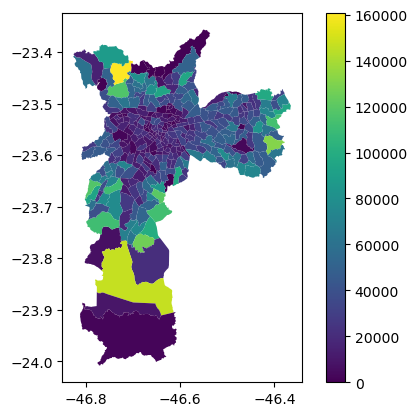

In [5]:
# Carrega o shapefile com as regiões (zonas ou subprefeituras)
# e os dados de população associados a cada região
mapa = gpd.read_file(f'{_base_map}/{identificacao}/map.shp')
pop = pd.read_csv(f'{_base_map}/{identificacao}/pop.csv')

pop = pop[pop['id'] != "Brazil"]

# Associa a população a cada geometria do mapa usando o ID
# Isso será usado depois para análises estruturais (ex: grau vs população)

mapa['pop'] = mapa['id'].map(lambda x: pop.set_index('id')['pop'].get(x,np.nan))

mapa.plot('pop', cmap='viridis', legend=True)

Inspecionando shapefile

In [6]:
mapa.head()

,id,geometry,pop
0,Sé,"POLYGON ((-46.62782 -23.55166, -46.62763 -23.5...",3513
1,Parque Dom Pedro,"POLYGON ((-46.63526 -23.54296, -46.63512 -23.5...",4142
2,Praça João Mendes,"POLYGON ((-46.633 -23.55646, -46.63413 -23.556...",16177
3,Ladeira da Memória,"POLYGON ((-46.63889 -23.54861, -46.63889 -23.5...",24406
4,República,"POLYGON ((-46.63647 -23.54442, -46.63627 -23.5...",14734


In [7]:
# abrir matrizes
fn_move_mat = f'{_base_mob}/date0=<DATE>/move_mat_Brasil_{identificacao}'
# print(fn_move_mat)

def get_data(fn, date):
    _fn = fn.replace('<DATE>', date)
    # print(f'{_fn}.npy')
    return np.load(f'{_fn}.npy').astype(float)

dates = list(pd.date_range('2019-01-01','2019-12-31').astype(str))

move_mat = get_data(fn_move_mat, dates[0])

#Acumulado das matrizes de mobilidade
for i in range(1,len(dates)):
    try:
        move_mat += get_data(fn_move_mat, dates[i])
    except:
        pass

# Carrega os nomes das regiões (zonas ou subprefeituras) associadas a cada índice da matriz de mobilidade
move_mat_reg = [x.strip() for x in open(f'{fn_move_mat.replace("<DATE>",dates[0])}_reg_names.txt').readlines()]  

# Verifica se os IDs das regiões na matriz de mobilidade correspondem aos IDs no mapa e na população
assert set(move_mat_reg) == set(pop['id'])
assert set(mapa['id']) == set(pop['id'])

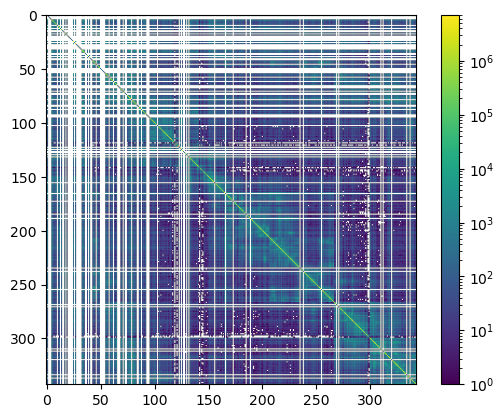

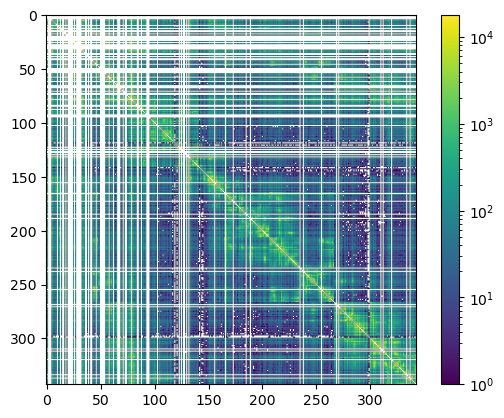

In [8]:
out_diagonal = move_mat.copy()
np.fill_diagonal(out_diagonal, 0.0) # Zera a diagonal para focar apenas nos movimentos entre regiões diferentes

plt.imshow(move_mat, norm='log')
plt.colorbar()
plt.show()
plt.clf()
plt.imshow(out_diagonal, norm='log')
plt.colorbar()
plt.show()

In [9]:
move_mat.shape

(343, 343)

### Considerando grafo direcionado

In [10]:
# Constrói o grafo direcionado/ponderado a partir da matriz de mobilidade
# Nós = regiões
# Arestas = fluxo de pessoas entre regiões
# Peso = intensidade do fluxo

G = nx.from_numpy_array(move_mat, create_using=nx.DiGraph)

# atributo com nome/ID da região
node_attrs = {i: {'id': move_mat_reg[i]} for i in range(len(move_mat_reg))}
nx.set_node_attributes(G, node_attrs)

##### 1. Estatística descritiva + mapas

In [11]:
## Fluxo total
weights = [d['weight'] for (_,_,d) in G.edges(data=True)]
print("Fluxo total:", sum(weights))

# In-degree e out-degree (estrutura básica correta)
in_deg = dict(G.in_degree())
print("In-degree:", in_deg)

out_deg = dict(G.out_degree())
print("Out-degree:", out_deg)

#Strength (grau ponderado)
in_strength = dict(G.in_degree(weight='weight'))
out_strength = dict(G.out_degree(weight='weight'))
print("In-strength:", in_strength)
print("Out-strength:", out_strength)

Fluxo total: 381876460.0
In-degree: {0: 1, 1: 274, 2: 1, 3: 1, 4: 1, 5: 275, 6: 274, 7: 272, 8: 273, 9: 273, 10: 1, 11: 272, 12: 274, 13: 1, 14: 272, 15: 1, 16: 1, 17: 275, 18: 1, 19: 274, 20: 1, 21: 1, 22: 1, 23: 1, 24: 1, 25: 274, 26: 1, 27: 275, 28: 1, 29: 1, 30: 1, 31: 1, 32: 1, 33: 273, 34: 273, 35: 273, 36: 1, 37: 1, 38: 272, 39: 1, 40: 273, 41: 1, 42: 1, 43: 271, 44: 271, 45: 270, 46: 1, 47: 272, 48: 273, 49: 273, 50: 1, 51: 1, 52: 1, 53: 1, 54: 1, 55: 274, 56: 275, 57: 273, 58: 1, 59: 272, 60: 275, 61: 274, 62: 1, 63: 274, 64: 271, 65: 274, 66: 1, 67: 1, 68: 1, 69: 272, 70: 274, 71: 1, 72: 274, 73: 1, 74: 1, 75: 273, 76: 275, 77: 275, 78: 275, 79: 1, 80: 275, 81: 275, 82: 274, 83: 275, 84: 1, 85: 1, 86: 275, 87: 275, 88: 1, 89: 272, 90: 275, 91: 274, 92: 274, 93: 1, 94: 1, 95: 1, 96: 274, 97: 273, 98: 273, 99: 273, 100: 273, 101: 272, 102: 271, 103: 1, 104: 263, 105: 273, 106: 266, 107: 273, 108: 271, 109: 273, 110: 272, 111: 272, 112: 273, 113: 269, 114: 271, 115: 274, 116: 27

##### Distribuição de graus (direcionado)

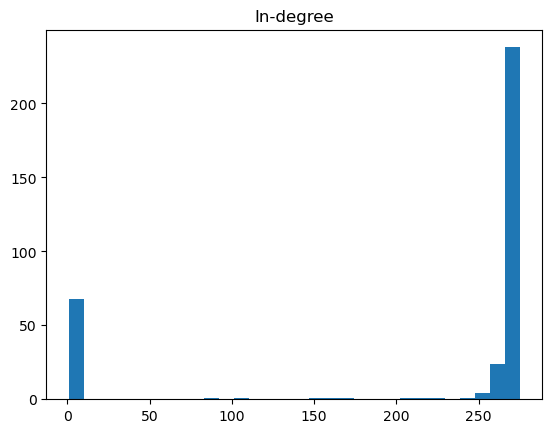

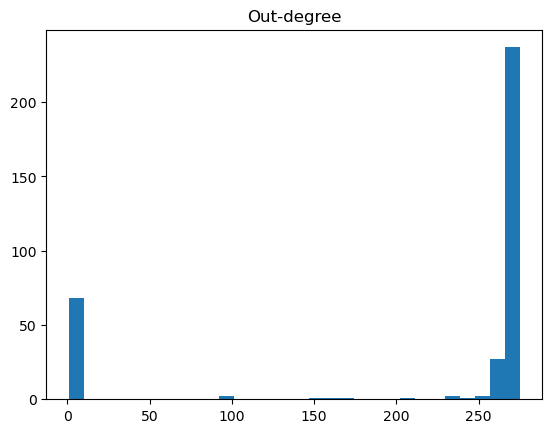

In [12]:
plt.hist(list(in_deg.values()), bins=30)
plt.title("In-degree")
plt.show()

plt.hist(list(out_deg.values()), bins=30)
plt.title("Out-degree")
plt.show()

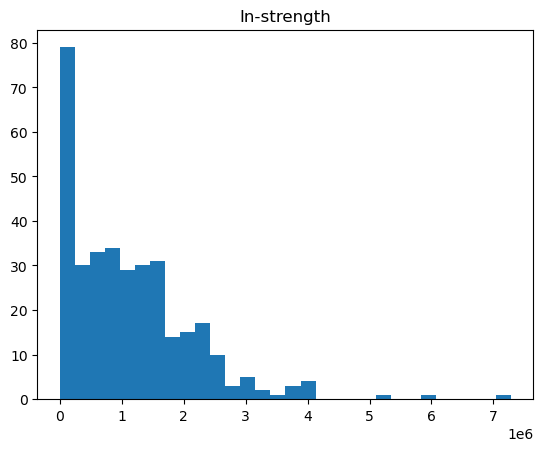

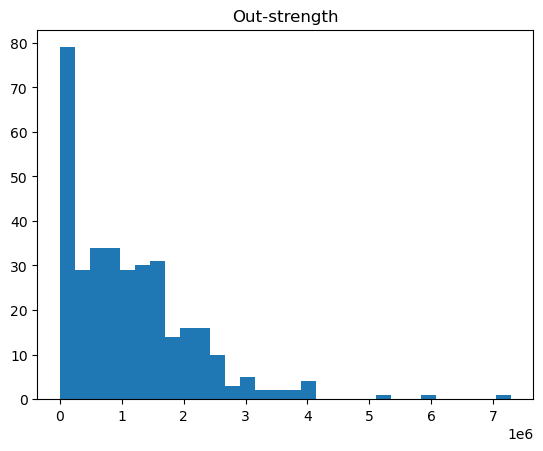

In [13]:
plt.hist(list(in_strength.values()), bins=30)
plt.title("In-strength")
plt.show()

plt.hist(list(out_strength.values()), bins=30)
plt.title("Out-strength")
plt.show()

##### Grau × clustering

DUVIDA CATIA:

G.to_undirected()" 
"An undirected graph with the same name and nodes and with edge (u, v, data) if either (u, v, data) or (v, u, data) is in the digraph. If both edges exist in digraph and their edge data is different, only one edge is created with an arbitrary choice of which edge data to use. You must check and correct for this manually if desired."

 - Faz sentido deixar ele escolher arbitrariamente a aresta usada se estamos analisando grafos nao-direcionados? Corrigir manualmente?
 - Faz sentido comparar clustering do grafo nao direcionado com as medidas in-strength e out-strength do grafo direcionado?

 (FIZ O MESMO COMENTARIO MAIS A FRENTE NA PARTE DAS COMUNIDADES)

In [14]:
# Clustering (coeficiente de agrupamento) considerando o grafo não-direcional e ponderado
clustering = nx.clustering(G.to_undirected(), weight='weight')

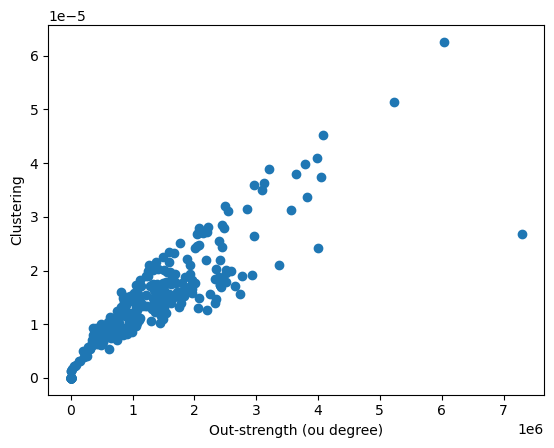

In [15]:
nodes = list(G.nodes())

deg = np.array([out_strength[n] for n in nodes])
clus = np.array([clustering[n] for n in nodes])

plt.scatter(deg, clus)
plt.xlabel("Out-strength (ou degree)")
plt.ylabel("Clustering")
plt.show()

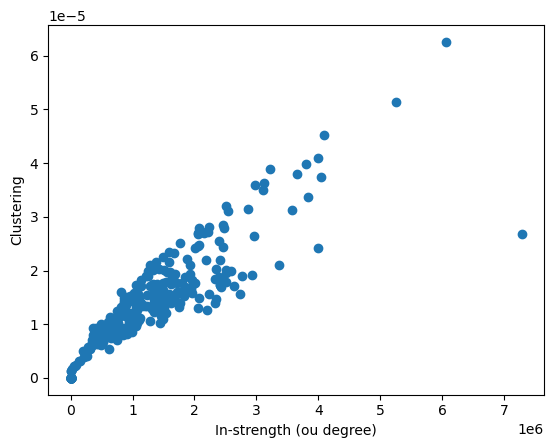

In [16]:
nodes = list(G.nodes())

deg = np.array([in_strength[n] for n in nodes])
clus = np.array([clustering[n] for n in nodes])

plt.scatter(deg, clus)
plt.xlabel("In-strength (ou degree)")
plt.ylabel("Clustering")
plt.show()

##### População × grau

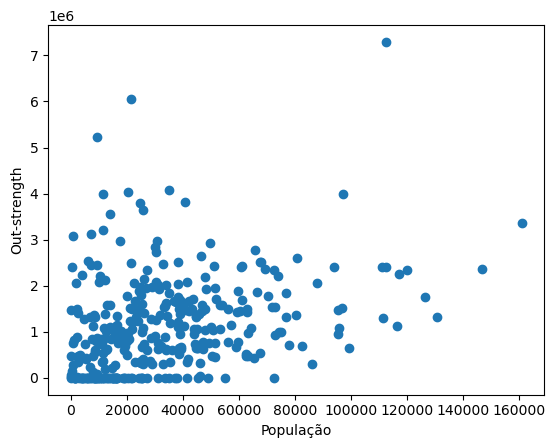

In [17]:
# Analisar a relação entre população e out-strength (mobilidade de saída)
pop_series = pop.set_index("id")["pop"]
nodes = list(G.nodes())

x = [pop_series[G.nodes[n]['id']] for n in nodes]
y = [out_strength[i] for i in nodes]

plt.scatter(x, y)
plt.xlabel("População")
plt.ylabel("Out-strength")
plt.show()

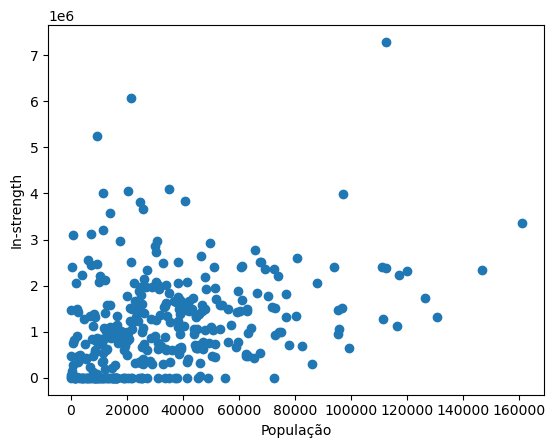

In [18]:
# Analisar a relação entre população e in-strength (mobilidade de entrada)
pop_series = pop.set_index("id")["pop"]
nodes = list(G.nodes())

x = [pop_series[G.nodes[n]['id']] for n in nodes]
y = [in_strength[i] for i in nodes]

plt.scatter(x, y)
plt.xlabel("População")
plt.ylabel("In-strength")
plt.show()

##### Out_strength X Retention

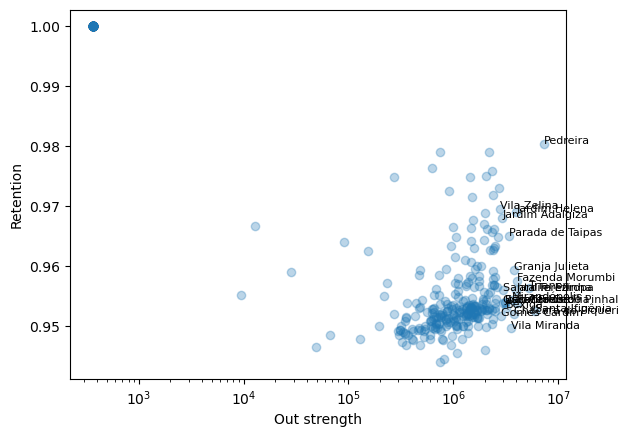

In [19]:
# soma das saídas (linha)
out_strength = move_mat.sum(axis=1)

# diagonal
diag = np.diag(move_mat)

# retenção
retention = diag / (out_strength + 1e-12)

# plot
#plt.scatter(out_strength, retention, alpha=0.5)

#for i, name in enumerate(move_mat_reg):
#    plt.text(out_strength[i], retention[i], name, fontsize=6)


idx = np.argsort(out_strength)[-20:]

plt.scatter(out_strength, retention, alpha=0.3)

for i in idx:
    plt.text(out_strength[i], retention[i], move_mat_reg[i], fontsize=8)


plt.xscale('log')
plt.xlabel("Out strength")
plt.ylabel("Retention")
plt.show()

In [20]:
dates = list(pd.date_range('2019-01-01','2019-12-31').astype(str))

total_mobility = []

# Calcula a mobilidade total (soma de todas as entradas da matriz) para cada data, excluindo as permanências (diagonal)
for d in dates:
    try:
        # Carrega a matriz de mobilidade para a data atual
        mat = get_data(fn_move_mat, d)
        # mobilidade total excluindo permanências (diagonal)
        total_mobility.append(mat.sum() - np.trace(mat))
    except:
        total_mobility.append(np.nan)

# Cria um DataFrame com as datas e a mobilidade total
mob_df = pd.DataFrame({"date": dates, "total_mobility": total_mobility})
# Converte a coluna de datas para o formato datetime
mob_df["date"] = pd.to_datetime(mob_df["date"])

<Axes: xlabel='date'>

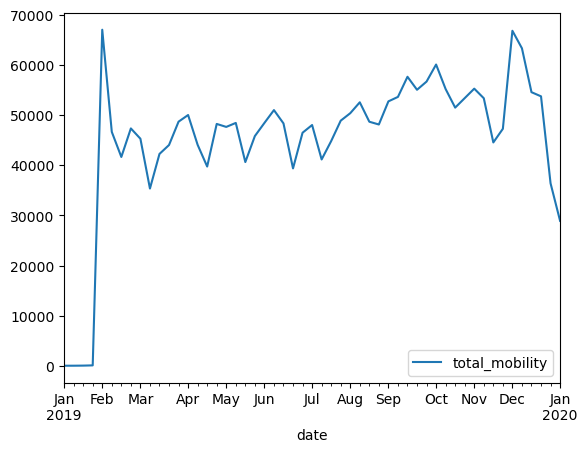

In [21]:
mob_df.set_index("date").resample("W").mean().plot()

In [22]:
dates = list(pd.date_range('2019-01-01','2019-12-31').astype(str))

# lista de regiões sem ids “#”
valid_idx = [i for i, x in enumerate(move_mat_reg) if '#' not in x]
valid_regions = [move_mat_reg[i] for i in valid_idx]

# listas para construir DataFrame
records = []

for d in dates:
    try:
        # Carrega a matriz de mobilidade para a data atual
        mat = get_data(fn_move_mat, d)

        # filtrar apenas regiões válidas
        mat = mat[np.ix_(valid_idx, valid_idx)]

        # calcular métricas para cada região
        total_mob = mat.sum() - np.trace(mat)
        
        # Calcula a força de saída (out strength) e entrada (in strength) para cada região
        out_strength = mat.sum(axis=1)
        in_strength  = mat.sum(axis=0)

        diag = np.diag(mat)

        # retenção e fluxo relativo
        retention = diag / (out_strength + 1e-12) # fração da mobilidade que permanece na própria região
        flow_rel = out_strength / (total_mob + 1e-12) # importância relativa da região no fluxo total da rede

        # adicionar registros para cada região
        for i, reg in enumerate(valid_regions):
            records.append({
                "date": pd.to_datetime(d),
                "id": reg,
                "total_mobility": total_mob,
                "out_strength": out_strength[i],
                "in_strength": in_strength[i],
                "retention": retention[i],
                "flow_rel": flow_rel[i]
            })

    except Exception as e:
        # caso falhe, coloca NaNs
        for reg in valid_regions:
            records.append({
                "date": pd.to_datetime(d),
                "id": reg,
                "total_mobility": np.nan,
                "out_strength": np.nan,
                "in_strength": np.nan,
                "retention": np.nan,
                "flow_rel": np.nan
            })

# criar DataFrame final
mob_region_df = pd.DataFrame(records)

# aplicar filtro extra (caso queira)
mob_region_df = mob_region_df[~mob_region_df['id'].str.contains('#')]

# setar a data como índice
mob_region_df = mob_region_df.set_index("date")

# resample por mês e agrupar por região
mob_region_df = mob_region_df.groupby("id").resample("W").mean().reset_index()

mob_region_df.head()

,id,date,total_mobility,out_strength,in_strength,retention,flow_rel
0,Aclimação,2019-01-06,23.166667,1.0,1.0,1.0,0.045719
1,Aclimação,2019-01-13,26.571429,1.0,1.0,1.0,0.040313
2,Aclimação,2019-01-20,44.857143,1.0,1.0,1.0,0.026486
3,Aclimação,2019-01-27,92.428571,1.0,1.0,1.0,0.011456
4,Aclimação,2019-02-03,67045.000000,1.0,1.0,1.0,0.001363


In [23]:
mob_region_df.shape

(18179, 7)

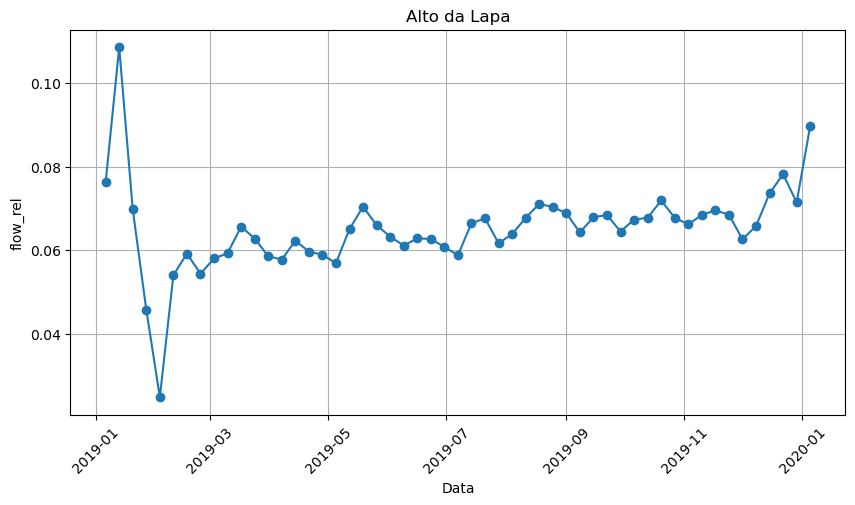

In [24]:
col = 'flow_rel'

# escolher região
region = "Alto da Lapa"  # ou qualquer id do seu DataFrame

# filtrar dados da região
df_reg = mob_region_df[mob_region_df['id'] == region]

plt.figure(figsize=(10,5))
plt.plot(df_reg['date'], df_reg[col], marker='o')
plt.title(f"{region}")
plt.xlabel("Data")
plt.ylabel(col)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

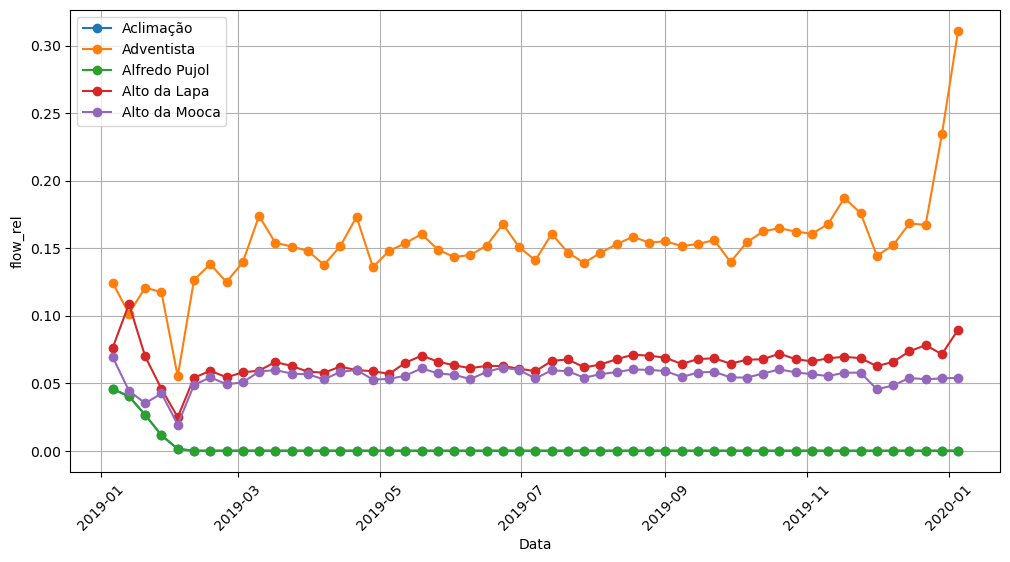

In [25]:
top_regions = mob_region_df.groupby("id")['total_mobility'].mean().sort_values(ascending=False).head(5).index

plt.figure(figsize=(12,6))
for reg in top_regions:
    df_reg = mob_region_df[mob_region_df['id'] == reg]
    plt.plot(df_reg['date'], df_reg['flow_rel'], marker='o', label=reg)

#plt.title("Mobilidade total mensal - top 5 regiões")
plt.xlabel("Data")
plt.ylabel("flow_rel")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

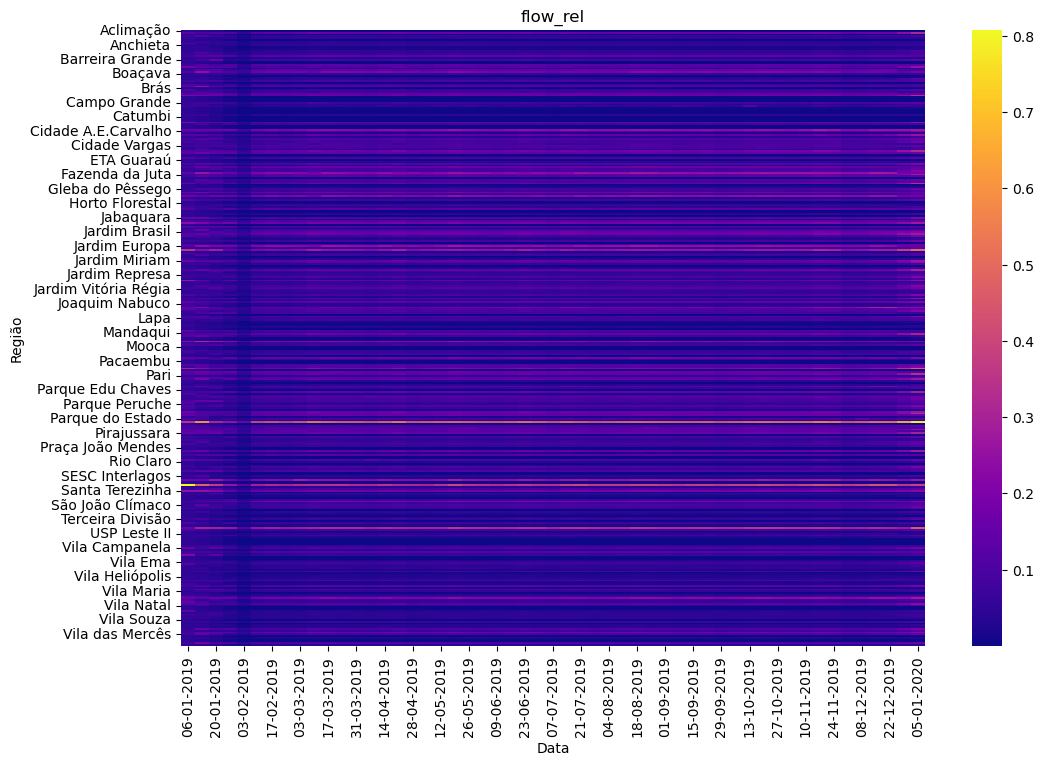

In [26]:
mob_pivot = mob_region_df.pivot_table(index='date', columns='id', values='flow_rel')

mob_pivot.index = pd.to_datetime(mob_pivot.index).strftime("%d-%m-%Y")

plt.figure(figsize=(12,8))
sns.heatmap(mob_pivot.T, cmap="plasma")
plt.title("flow_rel")
plt.xlabel("Data")
plt.ylabel("Região")
plt.show()

### Considerando grafo não direcionado

DUVIDA CATIA: 
"G_und = G.to_undirected()" 
"An undirected graph with the same name and nodes and with edge (u, v, data) if either (u, v, data) or (v, u, data) is in the digraph. If both edges exist in digraph and their edge data is different, only one edge is created with an arbitrary choice of which edge data to use. You must check and correct for this manually if desired."

 - Faz sentido deixar ele escolher arbitrariamente a aresta usada se estamos analisando grafos nao-direcionados? Corrigir manualmente?

 - Faz sentido encontrar as comunidades a partir desse grafo e depois comparar com out_strength e retention calculados no grafo nao direcionado?

In [27]:
# precisa de grafo não-direcionado
G_und = G.to_undirected()

# remover auto-loops (permanências) para focar apenas nas interações entre regiões diferentes
G_und.remove_edges_from(nx.selfloop_edges(G_und))

# Detecção de comunidades usando algoritmo de Louvain
# Objetivo: identificar grupos de regiões com forte interação interna
partition = community_louvain.best_partition(G_und, weight='weight',resolution=0.3)

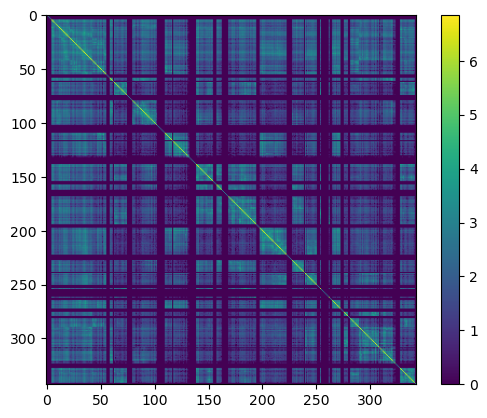

In [28]:
# Ordenar a matriz de mobilidade de acordo com as comunidades detectadas
order = sorted(range(len(partition)), key=lambda x: partition[x])
mat_sorted = move_mat[order][:, order]

plt.imshow(np.log10(mat_sorted + 1))
plt.colorbar()

In [29]:
# Criar DataFrame com a comunidade de cada região
df_comm = pd.DataFrame({
    "id": move_mat_reg,
    "community": [partition[i] for i in range(len(move_mat_reg))]
})

In [30]:
# Mesclar a informação de comunidade com o GeoDataFrame do mapa
gdf_comm = mapa.merge(df_comm, on="id", how="left")
gdf_comm = gdf_comm[~gdf_comm['id'].str.contains('#')]
gdf_comm

,id,geometry,pop,community
0,Sé,"POLYGON ((-46.62782 -23.55166, -46.62763 -23.5...",3513,0
1,Parque Dom Pedro,"POLYGON ((-46.63526 -23.54296, -46.63512 -23.5...",4142,5
2,Praça João Mendes,"POLYGON ((-46.633 -23.55646, -46.63413 -23.556...",16177,2
3,Ladeira da Memória,"POLYGON ((-46.63889 -23.54861, -46.63889 -23.5...",24406,3
4,República,"POLYGON ((-46.63647 -23.54442, -46.63627 -23.5...",14734,4
...,...,...,...,...
338,Jaguaré,"POLYGON ((-46.74461 -23.55841, -46.74494 -23.5...",33885,57
339,Cidade Universitária,"POLYGON ((-46.74444 -23.55842, -46.74431 -23.5...",2283,57
340,Butantã,"POLYGON ((-46.72311 -23.57253, -46.72313 -23.5...",6873,5
341,Jardim Caxingui,"POLYGON ((-46.72698 -23.57409, -46.72551 -23.5...",8514,57


0


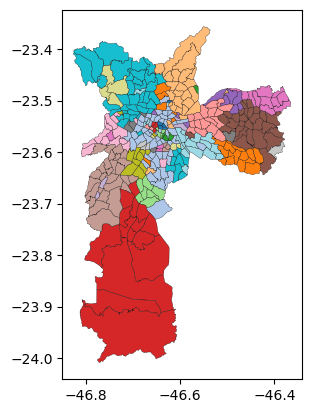

In [31]:
# Visualizar as comunidades no mapa
gdf_comm.plot(
    column="community",
    categorical=True,
    legend=False,
    cmap="tab20",
    edgecolor="black",
    linewidth=0.2
)
# Verificar quantas regiões ficaram sem comunidade atribuída (NaN)
print(gdf_comm["community"].isna().sum())

In [32]:
gdf_comm

,id,geometry,pop,community
0,Sé,"POLYGON ((-46.62782 -23.55166, -46.62763 -23.5...",3513,0
1,Parque Dom Pedro,"POLYGON ((-46.63526 -23.54296, -46.63512 -23.5...",4142,5
2,Praça João Mendes,"POLYGON ((-46.633 -23.55646, -46.63413 -23.556...",16177,2
3,Ladeira da Memória,"POLYGON ((-46.63889 -23.54861, -46.63889 -23.5...",24406,3
4,República,"POLYGON ((-46.63647 -23.54442, -46.63627 -23.5...",14734,4
...,...,...,...,...
338,Jaguaré,"POLYGON ((-46.74461 -23.55841, -46.74494 -23.5...",33885,57
339,Cidade Universitária,"POLYGON ((-46.74444 -23.55842, -46.74431 -23.5...",2283,57
340,Butantã,"POLYGON ((-46.72311 -23.57253, -46.72313 -23.5...",6873,5
341,Jardim Caxingui,"POLYGON ((-46.72698 -23.57409, -46.72551 -23.5...",8514,57


<Axes: >

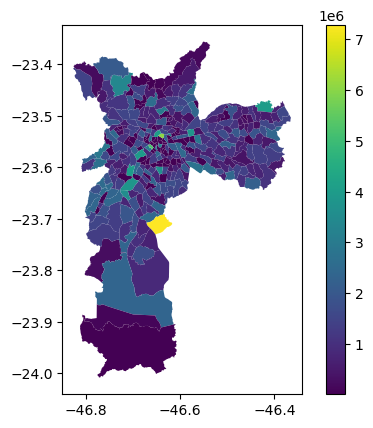

In [33]:
# Analisar a mobilidade total de saída (out strength) por comunidade
gdf_comm["out_strength"] = gdf_comm["id"].map(
    dict(zip(move_mat_reg, move_mat.sum(axis=1)))
)

gdf_comm.plot(column="out_strength", cmap="viridis", legend=True)

<Axes: >

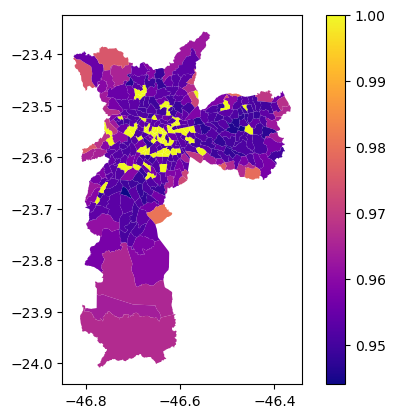

In [34]:
# Analisar a retenção (diagonal / out strength) por comunidade
diag = np.diag(move_mat)
out = move_mat.sum(axis=1)

ret = diag / (out + 1e-12)

gdf_comm["retention"] = gdf_comm["id"].map(
    dict(zip(move_mat_reg, ret))
)

gdf_comm.plot(column="retention", cmap="plasma", legend=True)